In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ue-city-dataset/SemanticClasses.csv
/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/RGB/rgb_frame_1206.jpg
/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/RGB/rgb_frame_932.jpg
/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/RGB/rgb_frame_2288.jpg
/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/RGB/rgb_frame_1416.jpg
/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/RGB/rgb_frame_1746.jpg
/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/RGB/rgb_frame_1159.jpg
/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/RGB/rgb_frame_767.jpg
/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/RGB/rgb_frame_1780.jpg
/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/RGB/rgb_frame_973.jpg
/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/RGB/rgb_frame_930.jpg
/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/RGB/rgb_frame_611.jpg
/kaggle/input/ue-cit

In [3]:
import torch.optim as optim
from tqdm import tqdm 
import matplotlib.pyplot as plt
import numpy as np
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [4]:
from torch.utils.data import Dataset
from PIL import Image
import os

class SemanticSegDataset(Dataset):
    def __init__(self, rgb_dir, mask_dir, rgb_transform=None, mask_transform=None):
        self.rgb_dir = rgb_dir
        self.mask_dir = mask_dir
        self.rgb_transform = rgb_transform
        self.mask_transform = mask_transform
        self.filenames = sorted(os.listdir(rgb_dir))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        rgb_name = self.filenames[idx]
        rgb_path = os.path.join(self.rgb_dir, rgb_name)
        mask_name = rgb_name.replace("rgb", "semantic")
        mask_path = os.path.join(self.mask_dir, mask_name)

        rgb = Image.open(rgb_path).convert("RGB")
        mask = Image.open(mask_path)

        if self.rgb_transform:
            rgb = self.rgb_transform(rgb)
        if self.mask_transform:
            mask = self.mask_transform(mask)

        return rgb, mask

In [5]:
import torchvision.transforms as T
from torch.utils.data import DataLoader

rgb_transform = T.Compose([
    T.Resize((512, 512)),
    T.ToTensor(),
])

mask_transform = T.Compose([
    T.Resize((512, 512), interpolation=Image.NEAREST),
    T.PILToTensor(),  # Keeps integer labels
])

train_dataset = SemanticSegDataset("/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/train/RGB", "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/train/Semantic", rgb_transform, mask_transform)
val_dataset = SemanticSegDataset("/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/RGB", "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/Semantic", rgb_transform, mask_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

In [6]:
import torchvision.models.segmentation as models
import torch.nn as nn
import torch

NUM_CLASSES = 9  # Change to your actual number of classes

model = models.deeplabv3_resnet50(weights="DEFAULT")
model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth
100%|██████████| 161M/161M [00:01<00:00, 91.7MB/s] 


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5, verbose=True, min_lr=2e-6)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [23]:
class EarlyStopping:
    def __init__(self, patience=20):
        self.patience = patience
        self.counter = 0
        self.best_acc = 0
        self.best_model_wts = None

    def step(self, acc, model):
        if acc > self.best_acc:
            self.best_acc = acc
            self.best_model_wts = model.state_dict()
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_model_wts:
            model.load_state_dict(self.best_model_wts)

early_stopping = EarlyStopping(patience=20)

In [24]:
class_colors = {
    "freeway deck": [0, 81, 33],
    "obstacles": [83, 21, 0],
    "traffic light": [0, 89, 254], 
    "decor": [142, 255, 145],
    "margin": [222, 118, 255],
    "building": [255, 239, 3],
    "car": [255, 0, 86],
    "road": [0, 184, 255],
    "sky": [255, 255, 255],
}

color_to_class = {tuple(rgb): idx for idx, (class_name, rgb) in enumerate(class_colors.items())}

def rgb_to_class_indices(batch_rgb_masks, color_to_class):
    batch_class_masks = []
    for rgb_mask in batch_rgb_masks:
        rgb_mask = rgb_mask.transpose(1, 2, 0)  # (C, H, W) to (H, W, C)
        class_mask = np.zeros(rgb_mask.shape[:2], dtype=np.int64)
        for color, class_idx in color_to_class.items():
            mask = np.all(rgb_mask == np.array(color), axis=-1)
            class_mask[mask] = class_idx
        batch_class_masks.append(torch.tensor(class_mask, dtype=torch.long))
    return torch.stack(batch_class_masks)

In [25]:
# Get the ID (index) of the 'traffic light' class
traffic_light_id = list(class_colors.keys()).index("traffic light")
print(f"The ID of 'traffic light' is: {traffic_light_id}")

The ID of 'traffic light' is: 2


In [26]:
import tensorflow as tf

num_classes = len(class_colors)
class_weights = np.ones(num_classes)
traffic_light_class_id = 2 # Replace with actual ID
class_weights = torch.ones(len(class_colors))  # All classes start with weight 1
class_weights[traffic_light_class_id] = 50.0  # Traffic light gets a higher weight

# Define the criterion with weighted cross-entropy loss
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

In [27]:
def compute_iou_dice(preds, masks, num_classes):
    ious = []
    dices = []
    preds = preds.view(-1)
    masks = masks.view(-1)
    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = masks == cls
        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()
        dice = (2 * intersection) / (pred_inds.sum() + target_inds.sum() + 1e-6)
        iou = intersection / (union + 1e-6)
        if target_inds.sum() > 0: 
            ious.append(iou.item())
            dices.append(dice.item())
    return sum(ious) / len(ious), sum(dices) / len(dices)

Validating: 100%|██████████| 93/93 [00:40<00:00,  2.30batch/s]


Epoch 1/10, Loss: 0.2276, Acc: 91.31%, Val Loss: 0.2244, Val Acc: 91.35%, IoU: 0.6272, Dice: 0.7122


Validating: 100%|██████████| 93/93 [00:41<00:00,  2.26batch/s]


Epoch 2/10, Loss: 0.1950, Acc: 92.22%, Val Loss: 0.2140, Val Acc: 91.60%, IoU: 0.6296, Dice: 0.7135


Validating: 100%|██████████| 93/93 [00:40<00:00,  2.30batch/s]


...

Epoch 8/10, Loss: 0.1326, Acc: 94.44%, Val Loss: 0.1964, Val Acc: 92.63%, IoU: 0.6655, Dice: 0.7470


Validating: 100%|██████████| 93/93 [00:40<00:00,  2.29batch/s]


Epoch 9/10, Loss: 0.1279, Acc: 94.64%, Val Loss: 0.2066, Val Acc: 92.58%, IoU: 0.6632, Dice: 0.7450


Validating: 100%|██████████| 93/93 [00:40<00:00,  2.28batch/s]


Epoch 10/10, Loss: 0.1291, Acc: 94.62%, Val Loss: 0.1994, Val Acc: 92.73%, IoU: 0.6716, Dice: 0.7527


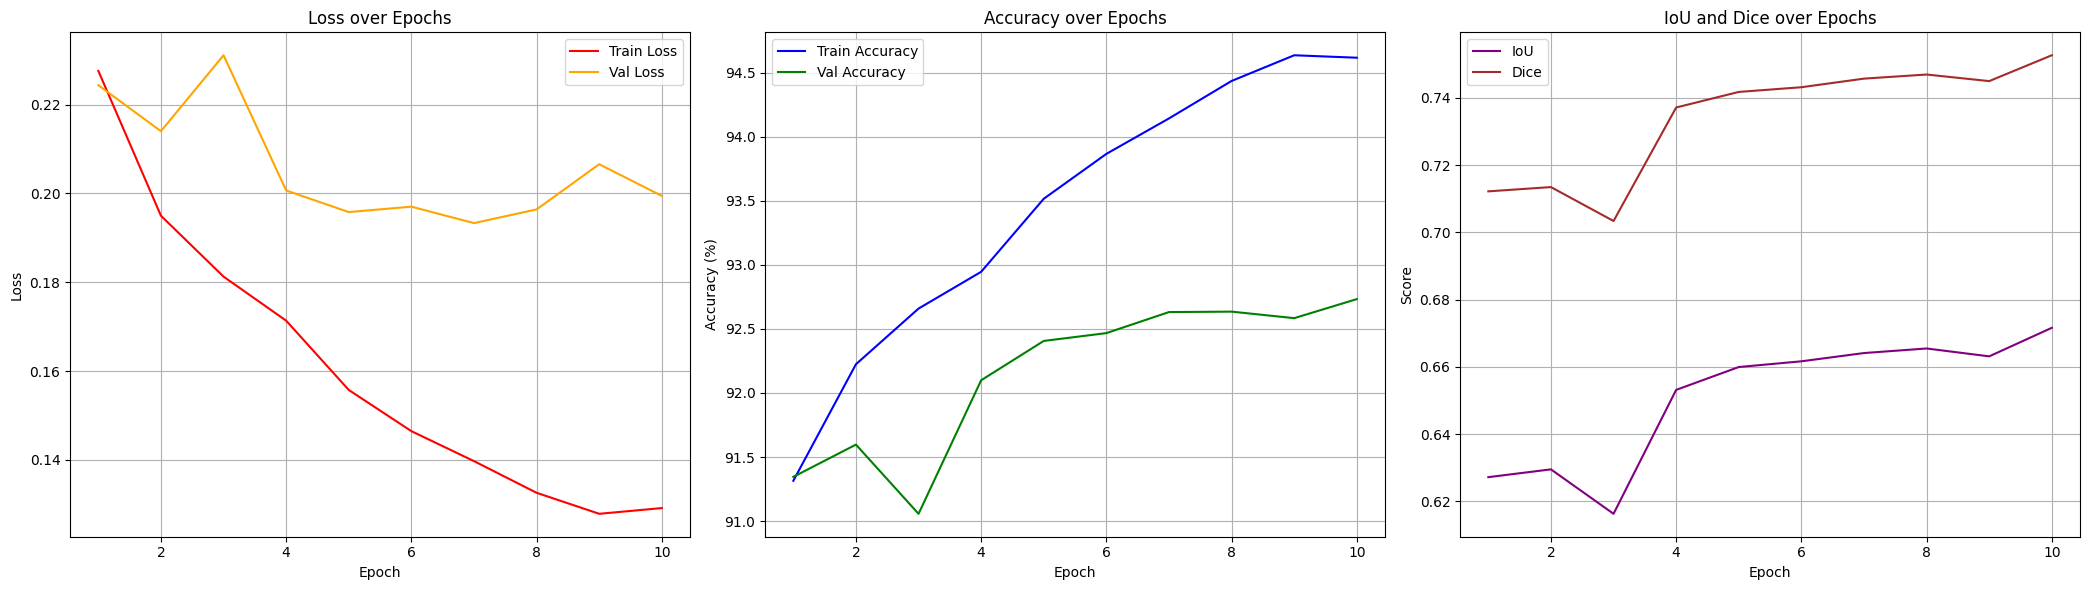

In [28]:
EPOCHS = 10
epoch_losses, epoch_accuracies, val_losses, val_accuracies = [], [], [], []
iou_scores, dice_scores = [], []

for epoch in range(EPOCHS):
    # -------- Training --------
    model.train()
    total_loss = 0
    total_correct = 0
    total_pixels = 0

    for images, rgb_masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Training", unit="batch"):
        images = images.to(device)
        masks = rgb_to_class_indices(rgb_masks.numpy(), color_to_class).to(device)

        outputs = model(images)['out']
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total_correct += (preds == masks).sum().item()
        total_pixels += masks.numel()

    avg_train_loss = total_loss / len(train_loader)
    train_accuracy = total_correct / total_pixels * 100
    epoch_losses.append(avg_train_loss)
    epoch_accuracies.append(train_accuracy)

    # -------- Validation --------
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    total_iou = 0
    total_dice = 0
    num_batches = 0

    with torch.no_grad():
        for images, rgb_masks in tqdm(val_loader, desc="Validating", unit="batch"):
            images = images.to(device)
            masks = rgb_to_class_indices(rgb_masks.numpy(), color_to_class).to(device)

            outputs = model(images)['out']
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == masks).sum().item()
            val_total += masks.numel()

            # Compute IoU and Dice
            iou, dice = compute_iou_dice(preds, masks, NUM_CLASSES)
            total_iou += iou
            total_dice += dice
            num_batches += 1

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = val_correct / val_total * 100
    avg_iou = total_iou / num_batches
    avg_dice = total_dice / num_batches

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    iou_scores.append(avg_iou)
    dice_scores.append(avg_dice)

    # Scheduler and Early Stopping
    scheduler.step(val_accuracy)
    stop = early_stopping.step(val_accuracy, model)

    print(f"Epoch {epoch+1}/{EPOCHS}, "
          f"Loss: {avg_train_loss:.4f}, Acc: {train_accuracy:.2f}%, "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%, "
          f"IoU: {avg_iou:.4f}, Dice: {avg_dice:.4f}")

    if stop:
        print("Early stopping triggered.")
        break

early_stopping.restore(model)
plt.figure(figsize=(21, 6))

plt.subplot(1, 3, 1)
plt.plot(range(1, len(epoch_losses)+1), epoch_losses, label='Train Loss', color='red')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss', color='orange')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(1, len(epoch_accuracies)+1), epoch_accuracies, label='Train Accuracy', color='blue')
plt.plot(range(1, len(val_accuracies)+1), val_accuracies, label='Val Accuracy', color='green')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(1, len(iou_scores)+1), iou_scores, label='IoU', color='purple')
plt.plot(range(1, len(dice_scores)+1), dice_scores, label='Dice', color='brown')
plt.title("IoU and Dice over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
import torch

# Save model weights
torch.save(model.state_dict(), 'deeplab_weights_v6_10epoch.pth')

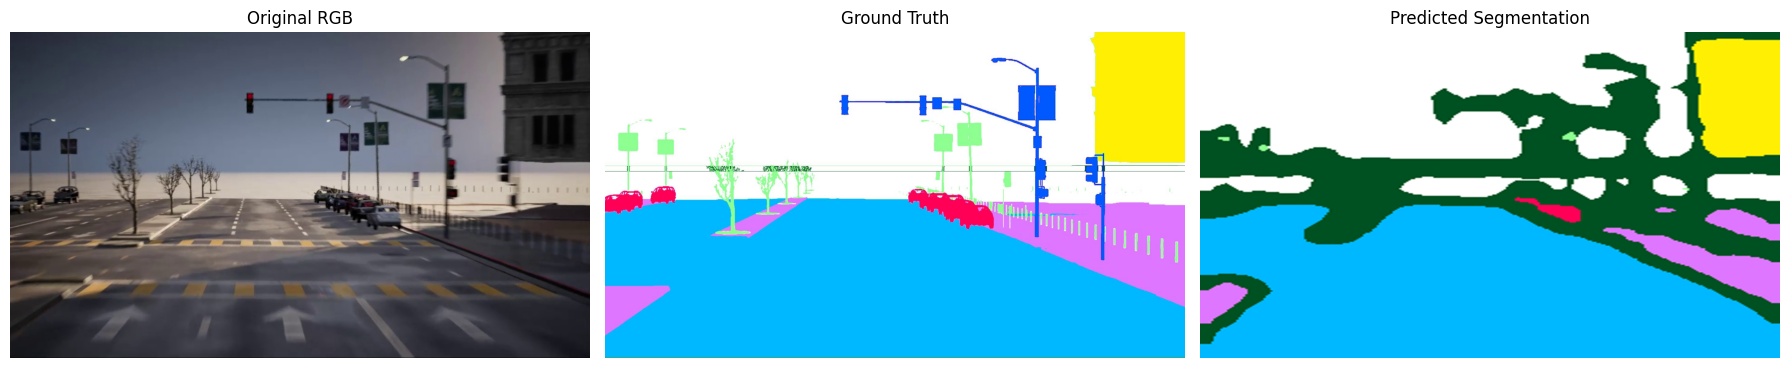

In [30]:
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

model.eval()

rgb_path = "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/test/RGB/rgb_frame_1035.jpg"               # ← Update
gt_mask_path = "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/test/Semantic/semantic_frame_1035.jpg" # ← Update

# Load RGB and GT mask
image = Image.open(rgb_path).convert("RGB")
gt_mask = Image.open(gt_mask_path).convert("RGB")
original_size = image.size

# Transform
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# Process input image
input_tensor = transform(image).unsqueeze(0).to(device)

# Inference
model.eval()
with torch.no_grad():
    output = model(input_tensor)['out']
    pred = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

# Decode prediction
def decode_segmentation(mask, class_colors):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for idx, (class_name, color) in enumerate(class_colors.items()):
        color_mask[mask == idx] = color
    return color_mask

pred_color = decode_segmentation(pred, class_colors)
pred_image_resized = Image.fromarray(pred_color).resize(original_size)

# Plot
plt.figure(figsize=(18, 6))

# Original RGB
plt.subplot(1, 3, 1)
plt.title("Original RGB")
plt.imshow(image)
plt.axis("off")

# Ground Truth
plt.subplot(1, 3, 2)
plt.title("Ground Truth")
plt.imshow(gt_mask)
plt.axis("off")

# Predicted Segmentation
plt.subplot(1, 3, 3)
plt.title("Predicted Segmentation")
plt.imshow(pred_image_resized)
plt.axis("off")

plt.tight_layout()
plt.show()

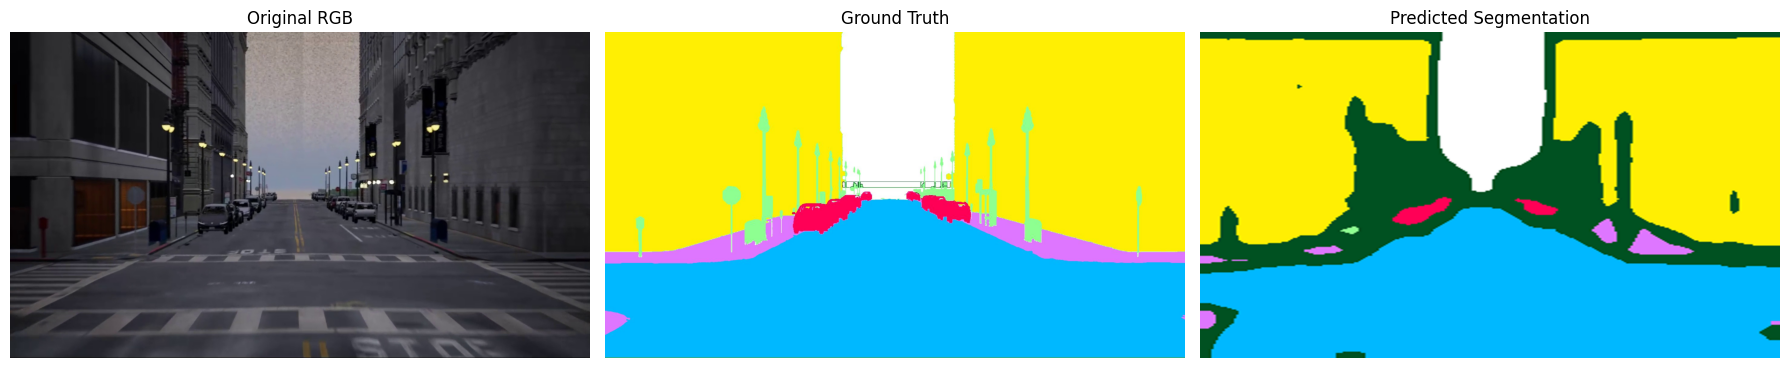

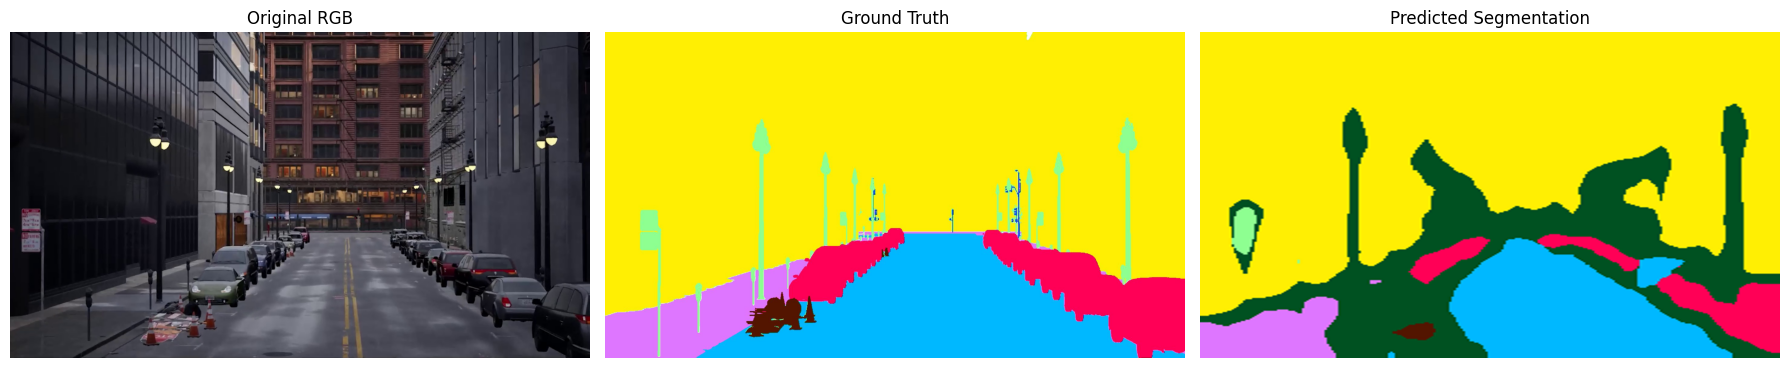

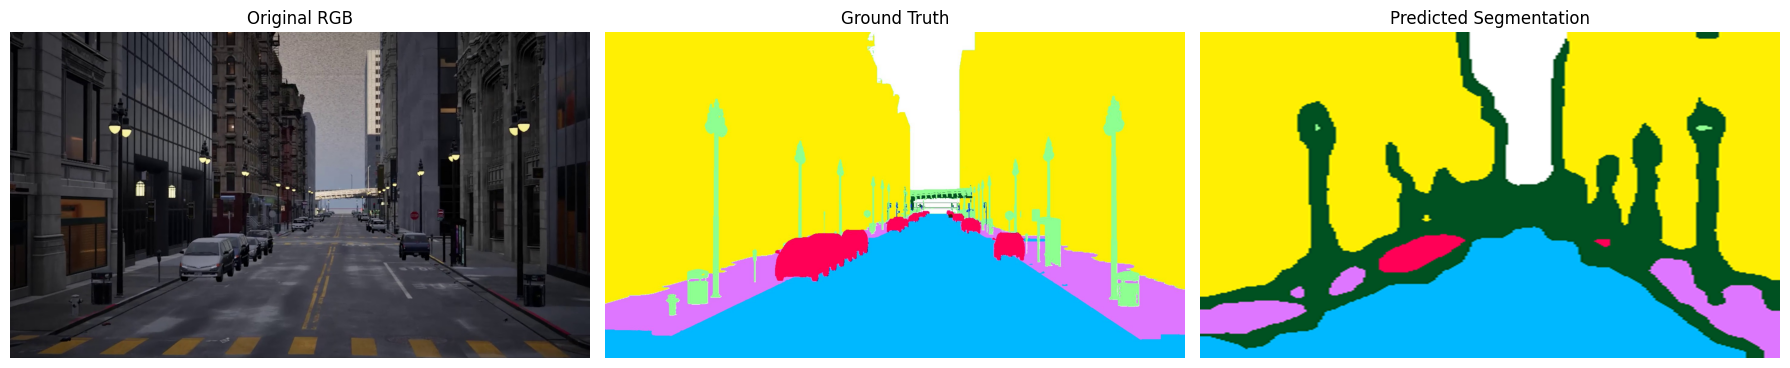

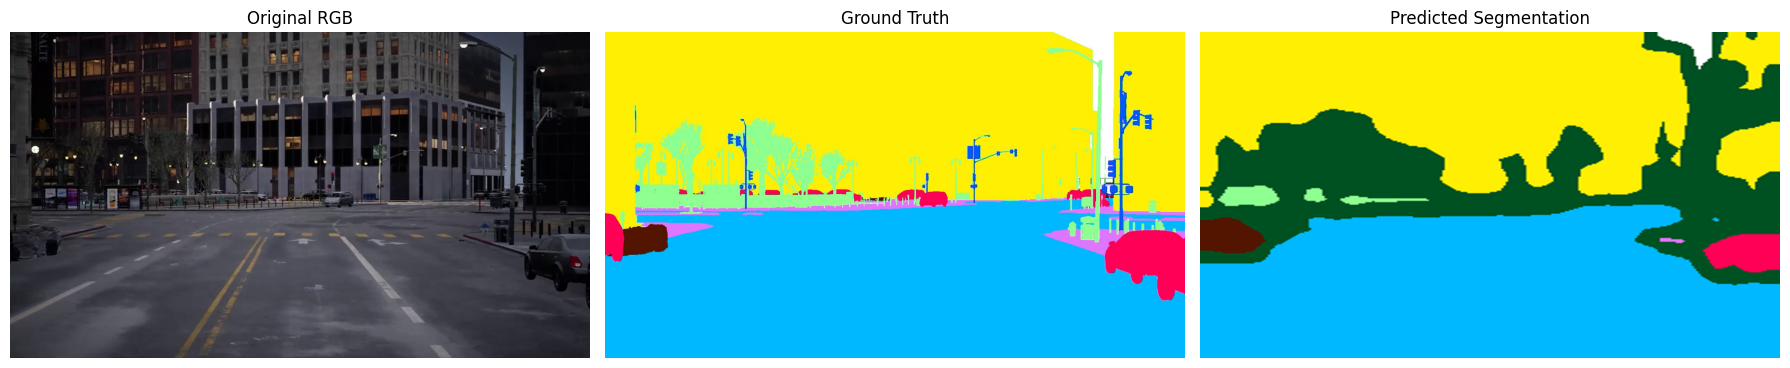

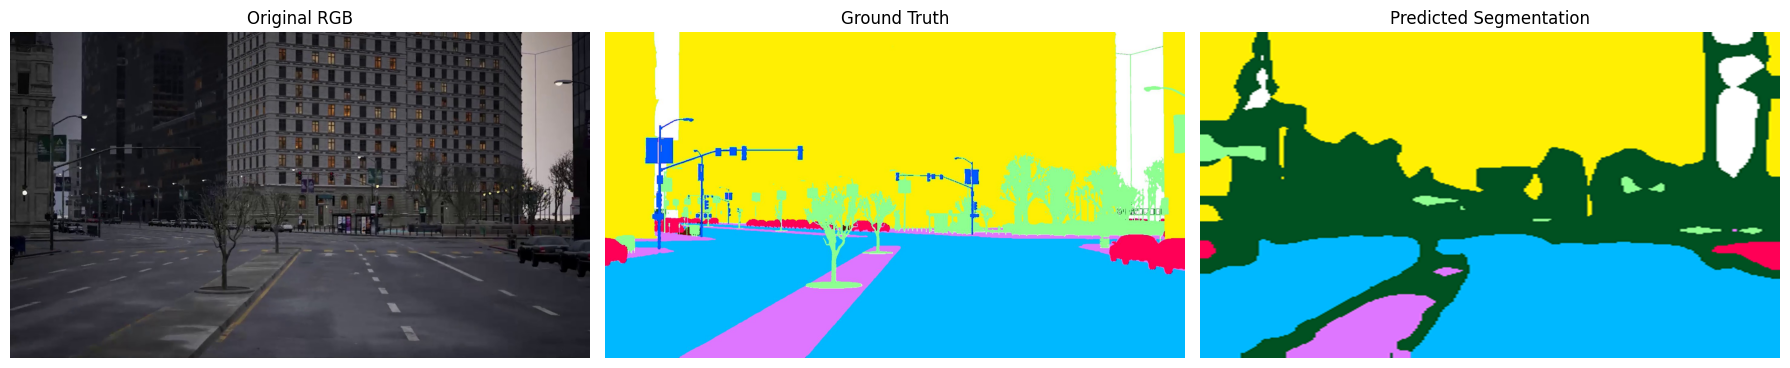

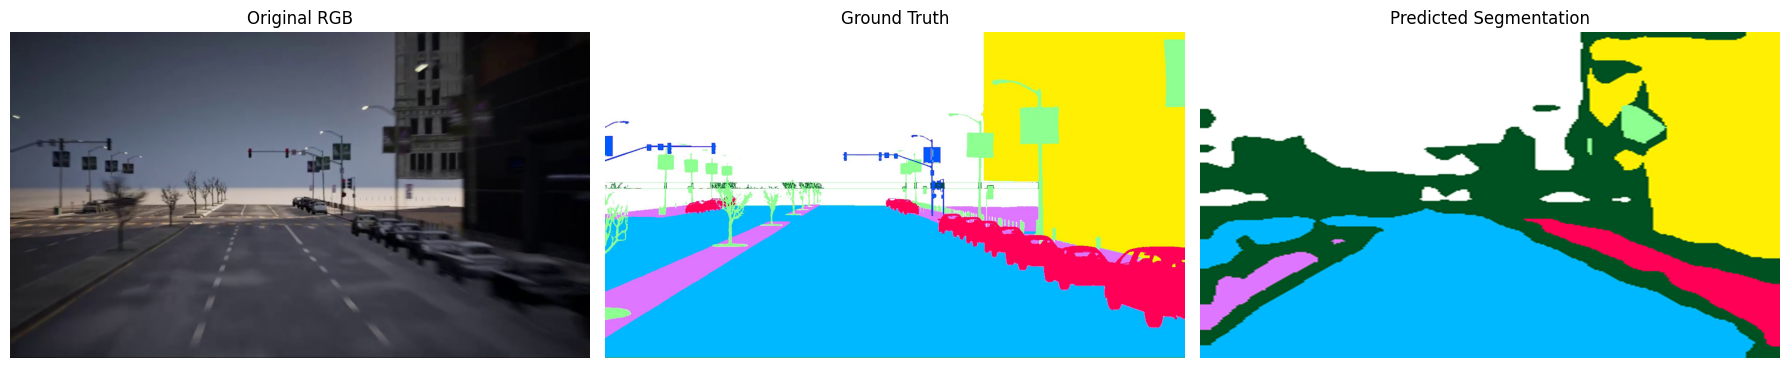

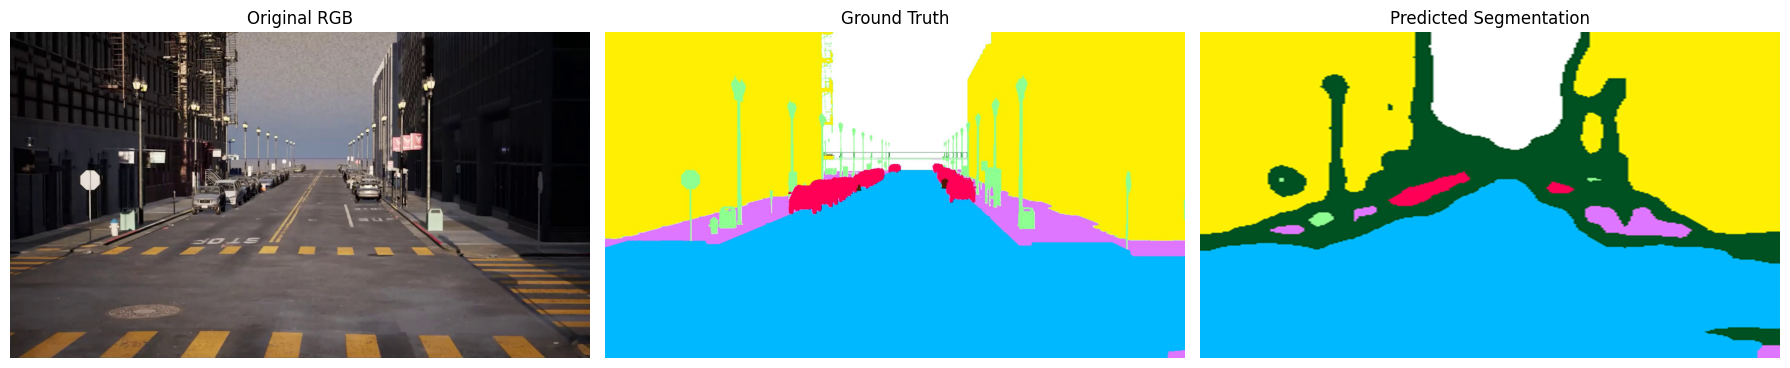

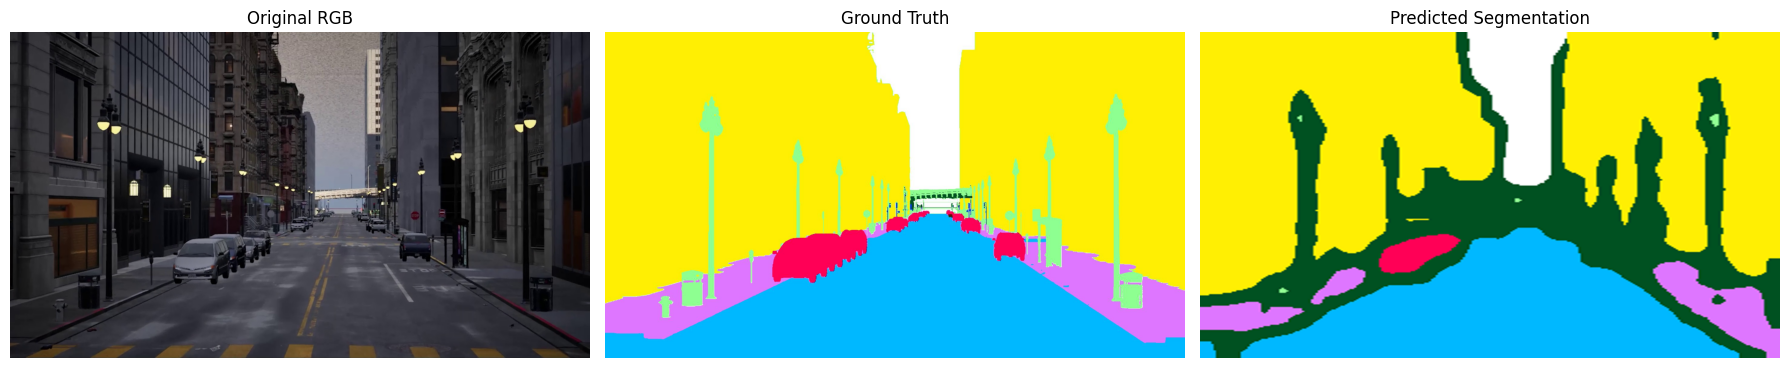

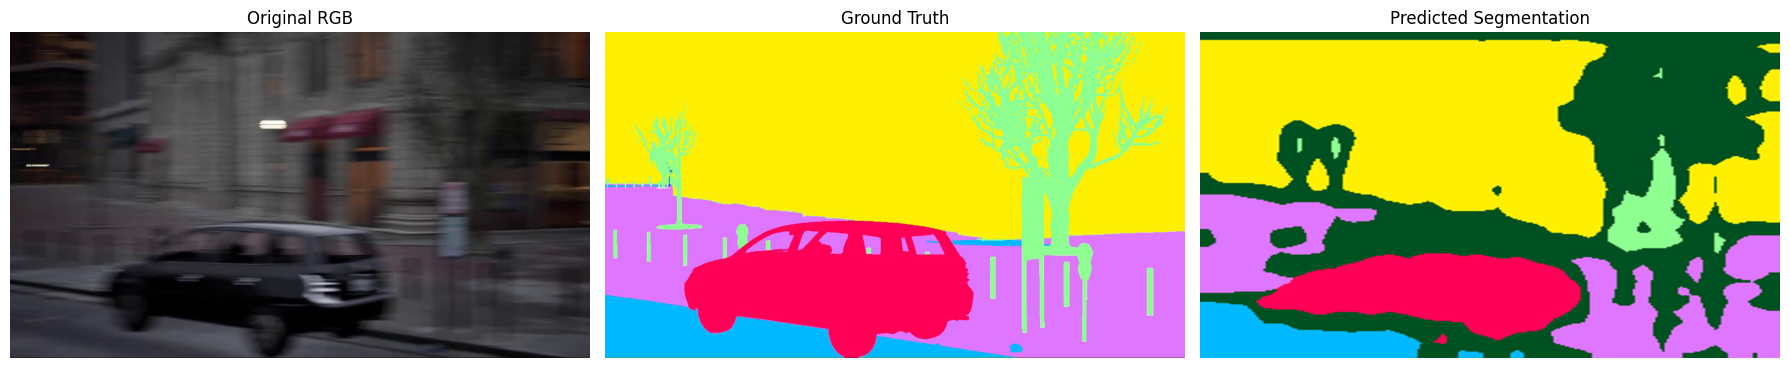

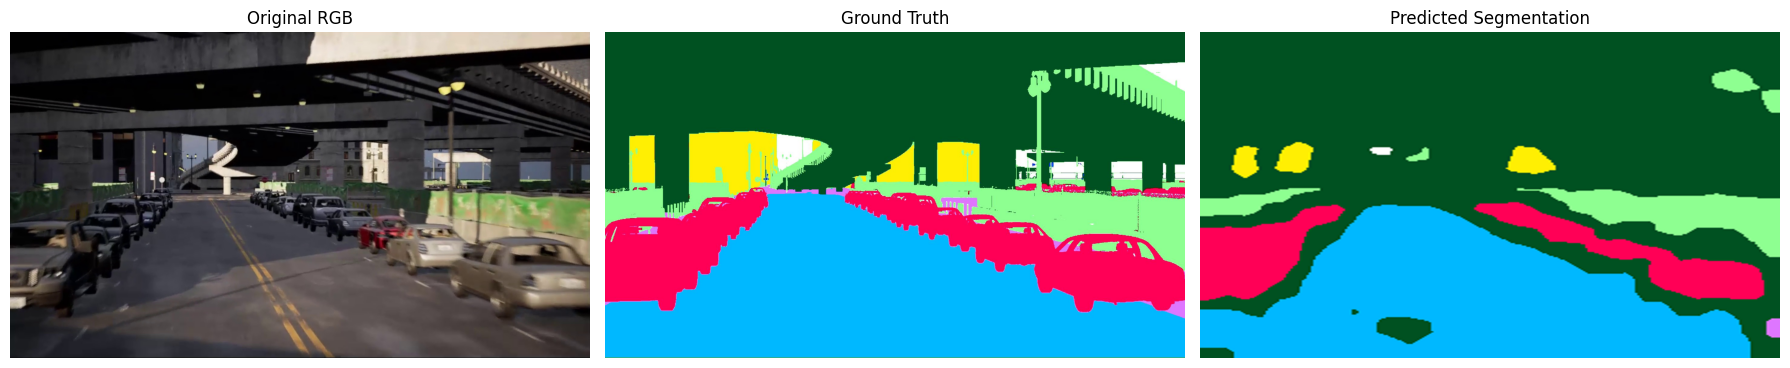

In [31]:
import os
import random
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Set model to eval mode
model.eval()

# Update paths
rgb_dir = "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/test/RGB"
gt_dir = "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/test/Semantic"

# Get all RGB filenames
rgb_files = sorted(os.listdir(rgb_dir))
random.shuffle(rgb_files)
rgb_files = rgb_files[:10]  # Select 10 random images

# Transform
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# Function to decode segmentation
def decode_segmentation(mask, class_colors):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for idx, (class_name, color) in enumerate(class_colors.items()):
        color_mask[mask == idx] = color
    return color_mask

# Inference and plot
for fname in rgb_files:
    rgb_path = os.path.join(rgb_dir, fname)
    gt_path = os.path.join(gt_dir, fname.replace("rgb", "semantic"))

    image = Image.open(rgb_path).convert("RGB")
    gt_mask = Image.open(gt_path).convert("RGB")
    original_size = image.size

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)['out']
        pred = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

    pred_color = decode_segmentation(pred, class_colors)
    pred_image_resized = Image.fromarray(pred_color).resize(original_size)

    # Plot
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.title("Original RGB")
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(gt_mask)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Predicted Segmentation")
    plt.imshow(pred_image_resized)
    plt.axis("off")

    plt.tight_layout()
    plt.show()